# Gemma3-SD Pure ELLA Long-Context Notebook

Goal: replace CLIP runtime with Gemma-derived conditioning via pure ELLA-style timestep-aware connector.

Main path:

```text
Gemma hidden states
  -> ELLA long-context connector
  -> [B, L, 768] context tokens, L in {77,128,192,256}
  -> original SD1.5 / StyleJourney UNet cross-attention
```

CLIP optional only:
- optional Phase 0 pretrain first 77 connector tokens against CLIP hidden states;
- optional teacher/text-delta loss during ELLA training;
- no CLIP needed for final inference.

No dual-native UNet surgery. No dense whole-UNet finetune. Phase 2 uses sparse SaRA-style adaptation on UNet `attn2.to_k/to_v` only.

## 0. Drive + installs

In [1]:
# @title 0.1 Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_OUT = '/content/drive/MyDrive/gemma3-sd-pure-ella'
os.makedirs(DRIVE_OUT, exist_ok=True)
print(f"Artifacts: {DRIVE_OUT}")


Mounted at /content/drive
Artifacts: /content/drive/MyDrive/gemma3-sd-pure-ella


In [2]:
# @title 0.2 Install deps — no Torch/NumPy changes
!pip install -q -U --upgrade-strategy only-if-needed \
  "Pillow==11.3.0" \
  "accelerate==1.6.0" \
  "transformers==4.54.1" \
  "diffusers[torch]==0.32.1" \
  "safetensors==0.4.5" \
  "datasets" \
  "ftfy" \
  "einops" \
  "wandb" \
  "matplotlib" \
  "tqdm" \
  "sentencepiece"

# Optional SaRA source kept for parity with prior notebook; this notebook uses explicit sparse-gradient SaRA-style path.
!git clone --depth 1 https://github.com/sjtuplayer/SaRA.git /content/SaRA 2>/dev/null || true
import sys
if "/content/SaRA" not in sys.path:
    sys.path.insert(0, "/content/SaRA")
try:
    from optim import adamw as sara_adamw
    print("SaRA import PASS")
except Exception as e:
    sara_adamw = None
    print(f"SaRA import SKIPPED: {type(e).__name__}: {e}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 155.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 126.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.8/434.8 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.3/27.3 MB 105.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 168.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# @title 0.3 Runtime check
import os, gc, math, time, random, json, io
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import transformers, diffusers, accelerate
print("Torch:", torch.__version__, "CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Transformers:", transformers.__version__)
print("Diffusers:", diffusers.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cuda.matmul.allow_tf32 = True


Torch: 2.10.0+cu128 CUDA: 12.8
GPU: NVIDIA L4
Transformers: 4.54.1
Diffusers: 0.32.1


In [4]:
# @title 0.4 HF + wandb secrets
from google.colab import userdata

hf_token = userdata.get("HF_TOKEN")
if not hf_token:
    raise ValueError("Missing HF_TOKEN in Colab secrets. Add via Colab key icon.")
os.environ["HF_TOKEN"] = hf_token
print("HF_TOKEN loaded")

import wandb
wb_key = userdata.get("WANDB_API_KEY") or userdata.get("WANDB_KEY")
if wb_key:
    os.environ["WANDB_API_KEY"] = wb_key
    WANDB_ENABLED = True
    print("wandb key loaded")
else:
    WANDB_ENABLED = False
    print("wandb disabled: no WANDB_API_KEY/WANDB_KEY")


HF_TOKEN loaded
wandb key loaded


## 1. Config

In [5]:
# @title 1.1 Run config
EXPERIMENT_STAGE = "stage1_77_pretrain_then_ella"  # @param ["stage1_77_pretrain_then_ella", "stage2_long_context_no_sara", "stage3_long_context_with_sara"]
LONG_CONTEXT_TARGET = 128  # @param [128, 192, 256]
RUN_MODE = "short_train"  # @param ["diagnostic", "overfit_train", "short_train", "full_train"]
RUN_TRAINING = RUN_MODE in {"overfit_train", "short_train", "full_train"}
RUN_FINAL_PROOF = True
RUN_FIXED_VALIDATION_GRIDS = True

# Core experiment: pure ELLA. CLIP alignment optional pretrain/diagnostic, not runtime path.
RUN_CLIP_ALIGNMENT_PRETRAIN = True  # @param {type:"boolean"}
USE_CLIP_TEACHER_DELTA = True       # @param {type:"boolean"}
USE_CLIP_TEACHER_DELTA_PHASE2 = False  # @param {type:"boolean"}  # keep Phase 2 teacher fixed unless you explicitly clone a frozen teacher UNet
ENABLE_UNET_GRADIENT_CHECKPOINTING = True  # @param {type:"boolean"}
PHASE1_SEMANTIC_ANCHOR_WEIGHT = 0.05  # small tether to preserve first-77 token geometry during frozen-UNet ELLA training
PHASE2_SEMANTIC_ANCHOR_WEIGHT = 0.05  # small tether to preserve first-77 token geometry during sparse Phase 2 adaptation

assert LONG_CONTEXT_TARGET in {128, 192, 256}
if EXPERIMENT_STAGE == "stage1_77_pretrain_then_ella":
    CONTEXT_TOKENS = 77
elif EXPERIMENT_STAGE in {"stage2_long_context_no_sara", "stage3_long_context_with_sara"}:
    CONTEXT_TOKENS = LONG_CONTEXT_TARGET
else:
    raise ValueError(EXPERIMENT_STAGE)

CLIP_ANCHOR_TOKENS = 77
RUN_SARA_PHASE = EXPERIMENT_STAGE == "stage3_long_context_with_sara"
RUN_RELOADED_LONG_PROOF = CONTEXT_TOKENS > CLIP_ANCHOR_TOKENS
assert CONTEXT_TOKENS in {77, 128, 192, 256}
assert CONTEXT_TOKENS >= CLIP_ANCHOR_TOKENS
assert not RUN_SARA_PHASE or CONTEXT_TOKENS > CLIP_ANCHOR_TOKENS, "Sparse SaRA stage is only for post-77-token expansion runs"

BASE_SEED = 1234
random.seed(BASE_SEED); np.random.seed(BASE_SEED); torch.manual_seed(BASE_SEED)

if RUN_MODE == "overfit_train":
    MAX_SAMPLES_PRETRAIN = 64
    MAX_SAMPLES_ELLA = 64
    PRETRAIN_EPOCHS = 20
    ELLA_EPOCHS = 40
    SARA_EPOCHS = 20
    PRETRAIN_MAX_OPT_STEPS = 300
    ELLA_MAX_OPT_STEPS = 600
    SARA_MAX_OPT_STEPS = 400
    VALIDATION_EVERY_OPT_STEPS = 50
    SHUFFLE_STREAMING = False
elif RUN_MODE == "short_train":
    MAX_SAMPLES_PRETRAIN = 6_000
    MAX_SAMPLES_ELLA = 6_000
    PRETRAIN_EPOCHS = 1
    ELLA_EPOCHS = 1
    SARA_EPOCHS = 1
    PRETRAIN_MAX_OPT_STEPS = 1_500
    ELLA_MAX_OPT_STEPS = 1_500
    SARA_MAX_OPT_STEPS = 500
    VALIDATION_EVERY_OPT_STEPS = 250
    SHUFFLE_STREAMING = True
elif RUN_MODE == "full_train":
    MAX_SAMPLES_PRETRAIN = 50_000
    MAX_SAMPLES_ELLA = 50_000
    PRETRAIN_EPOCHS = 1
    ELLA_EPOCHS = 1
    SARA_EPOCHS = 1
    PRETRAIN_MAX_OPT_STEPS = 12_500
    ELLA_MAX_OPT_STEPS = 12_500
    SARA_MAX_OPT_STEPS = 4_000
    VALIDATION_EVERY_OPT_STEPS = 500
    SHUFFLE_STREAMING = True
elif RUN_MODE == "diagnostic":
    MAX_SAMPLES_PRETRAIN = 128
    MAX_SAMPLES_ELLA = 128
    PRETRAIN_EPOCHS = 0
    ELLA_EPOCHS = 0
    SARA_EPOCHS = 0
    PRETRAIN_MAX_OPT_STEPS = 0
    ELLA_MAX_OPT_STEPS = 0
    SARA_MAX_OPT_STEPS = 0
    VALIDATION_EVERY_OPT_STEPS = 0
    SHUFFLE_STREAMING = True
else:
    raise ValueError(RUN_MODE)

TRAIN_BATCH_SIZE = 4
SHUFFLE_BUFFER = 10_000
GRAD_CLIP_NORM = 0.5

GEMMA_ID = "google/gemma-3-270m-it"
GEMMA_LAYER_INDEX = -1
MAX_GEMMA_LEN = 256
CLIP_ID = "openai/clip-vit-large-patch14"

CONNECTOR_WIDTH = 768
CONNECTOR_LAYERS = 4
CONNECTOR_HEADS = 8
CONNECTOR_FF_MULT = 4
CONNECTOR_DROPOUT = 0.0
CONNECTOR_TIME_EMBED_DIM = 768
CONNECTOR_EXTRA_GATE_INIT = -5.0

PRETRAIN_LR = 1e-4
ELLA_LR = 1e-4
SARA_LR = 1e-5
LAMBDA_DIFFUSION = 1.0
LAMBDA_TEACHER = 0.5
LAMBDA_TEXT_DELTA = 1.0

# SaRA-style sparse adaptation limited to SD text interface.
SARA_SCOPE = "attn2_kv_sparse"
SARA_TARGET_SUBSTRINGS = ("attn2.to_k", "attn2.to_v")
SARA_THRESHOLD = 1e-3
SARA_MAX_SPARSE_FRACTION_WARN = 0.02
SARA_MAX_SPARSE_FRACTION_ABORT = 0.05

VAL_PROMPTS = [
    "a cat sitting on a windowsill looking outside",
    "a watercolor painting of a mountain lake",
    "a neon-lit cyberpunk alleyway at night",
]
LONG_EVAL_SHORT_CONTROLS = [
    "a cinematic photo of a red vintage motorcycle parked beside a stone cottage",
    "a detailed product photograph of hiking boots on a wooden table",
]
LONG_EVAL_PROMPTS = [
    "a cinematic photo of a red vintage motorcycle parked beside a stone cottage, with a brass telescope on the seat, blue wildflowers in the basket, and a tiny owl perched on the handlebar at sunrise",
    "a detailed product photograph of hiking boots on a wooden table, with orange laces, a folded trail map, a silver compass, and raindrops on the leather",
]
VAL_SEED = 42
VAL_STEPS = 30
VAL_GUIDANCE = 5.0

RUN_CONFIG = {k: v for k, v in globals().items() if k.isupper() and isinstance(v, (str, int, float, bool, tuple, list, type(None)))}
print(json.dumps({k: RUN_CONFIG[k] for k in [
    "EXPERIMENT_STAGE", "RUN_MODE", "RUN_CLIP_ALIGNMENT_PRETRAIN", "USE_CLIP_TEACHER_DELTA",
    "CONTEXT_TOKENS", "CLIP_ANCHOR_TOKENS", "RUN_SARA_PHASE", "RUN_RELOADED_LONG_PROOF", "SARA_SCOPE"
]}, indent=2))
if EXPERIMENT_STAGE == "stage1_77_pretrain_then_ella" and not RUN_CLIP_ALIGNMENT_PRETRAIN:
    print("Stage 1 note: optional CLIP alignment pretrain disabled by user; notebook will run direct pure ELLA from random connector init.")

if WANDB_ENABLED:
    wandb.init(project="gemma3-sd-pure-ella", name=f"pure-ella-{EXPERIMENT_STAGE}-{RUN_MODE}-L{CONTEXT_TOKENS}", config=RUN_CONFIG)
else:
    class _NoWandb:
        def log(self, *args, **kwargs): pass
        def finish(self): pass
    wandb = _NoWandb()


{
  "EXPERIMENT_STAGE": "stage1_77_pretrain_then_ella",
  "RUN_MODE": "short_train",
  "RUN_CLIP_ALIGNMENT_PRETRAIN": true,
  "USE_CLIP_TEACHER_DELTA": true,
  "CONTEXT_TOKENS": 77,
  "CLIP_ANCHOR_TOKENS": 77,
  "RUN_SARA_PHASE": false,
  "RUN_RELOADED_LONG_PROOF": false,
  "SARA_SCOPE": "attn2_kv_sparse"
}


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: mistic-jedi to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 2. Models

In [6]:
# @title 2.1 Load Gemma
from transformers import AutoTokenizer, AutoModelForCausalLM

print(f"Loading Gemma: {GEMMA_ID}")
gemma_tokenizer = AutoTokenizer.from_pretrained(GEMMA_ID, token=os.environ.get("HF_TOKEN"))
if gemma_tokenizer.pad_token is None:
    gemma_tokenizer.pad_token = gemma_tokenizer.eos_token

gemma_model = AutoModelForCausalLM.from_pretrained(
    GEMMA_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    token=os.environ.get("HF_TOKEN"),
    low_cpu_mem_usage=True,
).eval()
for p in gemma_model.parameters():
    p.requires_grad_(False)

gemma_hidden_size = gemma_model.config.hidden_size
print("Gemma hidden_size:", gemma_hidden_size)
print("Gemma dtype:", next(gemma_model.parameters()).dtype)
assert gemma_hidden_size == 640, f"Expected Gemma 270M hidden_size 640, got {gemma_hidden_size}"


Loading Gemma: google/gemma-3-270m-it


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

...

chat_template.jinja: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/536M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

Gemma hidden_size: 640
Gemma dtype: torch.bfloat16


In [7]:
# @title 2.2 Load CLIP only if needed for optional pretrain / teacher delta
from transformers import CLIPTextModel, CLIPTokenizer

NEED_CLIP = RUN_CLIP_ALIGNMENT_PRETRAIN or USE_CLIP_TEACHER_DELTA or RUN_FIXED_VALIDATION_GRIDS
if NEED_CLIP:
    print(f"Loading CLIP teacher: {CLIP_ID}")
    clip_tokenizer = CLIPTokenizer.from_pretrained(CLIP_ID)
    clip_model = CLIPTextModel.from_pretrained(CLIP_ID, torch_dtype=torch.float16).to(device).eval()
    for p in clip_model.parameters():
        p.requires_grad_(False)
    clip_hidden_size = clip_model.config.hidden_size
    assert clip_hidden_size == 768
    print("CLIP loaded as teacher/diagnostic only")
else:
    clip_tokenizer = None
    clip_model = None
    clip_hidden_size = 768
    print("CLIP not loaded")


Loading CLIP teacher: openai/clip-vit-large-patch14


tokenizer_config.json:   0%|          | 0.00/905 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

CLIP loaded as teacher/diagnostic only


In [8]:
# @title 2.3 Load StyleJourney SD UNet + VAE + scheduler
from diffusers import StableDiffusionPipeline, DDPMScheduler, DPMSolverMultistepScheduler

SD_CHECKPOINT_CANDIDATES = [
    "/content/drive/MyDrive/model/stylejourney_v10.safetensors",
    "/models/stylejourney_v10.safetensors",
]

def resolve_sd_checkpoint():
    for path in SD_CHECKPOINT_CANDIDATES:
        if os.path.exists(path):
            return path
    raise FileNotFoundError("stylejourney_v10.safetensors not found in: " + ", ".join(SD_CHECKPOINT_CANDIDATES))

SD_CHECKPOINT = resolve_sd_checkpoint()
print("Loading SD checkpoint:", SD_CHECKPOINT)

def load_stylejourney_components(torch_dtype=torch.float32, target_device=device):
    pipe = StableDiffusionPipeline.from_single_file(
        SD_CHECKPOINT,
        torch_dtype=torch_dtype,
        safety_checker=None,
        requires_safety_checker=False,
    )
    base_unet = pipe.unet.to(target_device)
    base_vae = pipe.vae.to(target_device).eval()
    train_scheduler = DDPMScheduler.from_config(pipe.scheduler.config)
    pipe.text_encoder = None
    pipe.tokenizer = None
    pipe.safety_checker = None
    del pipe
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return base_unet, base_vae, train_scheduler

unet, vae, scheduler = load_stylejourney_components(torch_dtype=torch.float32, target_device=device)
if ENABLE_UNET_GRADIENT_CHECKPOINTING:
    unet.enable_gradient_checkpointing()
    print("UNet gradient checkpointing: ON")
else:
    print("UNet gradient checkpointing: OFF")
unet_dtype = next(unet.parameters()).dtype
assert int(unet.config.cross_attention_dim) == 768
print("UNet dtype:", unet_dtype)
print("UNet cross_attention_dim:", unet.config.cross_attention_dim)
print("No UNet surgery. Original cross-attn stays intact.")


Loading SD checkpoint: /content/drive/MyDrive/model/stylejourney_v10.safetensors


Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Some weights of the model checkpoint were not used when initializing CLIPTextModel: 
 ['text_model.embeddings.position_ids']
In this conversion only the non-EMA weights are extracted. If you want to instead extract the EMA weights (usually better for inference), please make sure to add the `--extract_ema` flag.


UNet gradient checkpointing: ON
UNet dtype: torch.float32
UNet cross_attention_dim: 768
No UNet surgery. Original cross-attn stays intact.


## 3. Encoding + connector

In [9]:
# @title 3.1 Encoding helpers + stage utilities
def _as_prompt_list(x):
    if isinstance(x, str):
        return [x]
    if isinstance(x, (list, tuple)):
        return [str(v) for v in x]
    return [str(v) for v in list(x)]

@torch.no_grad()
def encode_gemma_prompts(prompts, max_length=MAX_GEMMA_LEN):
    toks = gemma_tokenizer(
        _as_prompt_list(prompts),
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    ).to(gemma_model.device)
    out = gemma_model(**toks, output_hidden_states=True, use_cache=False)
    layers = out.hidden_states
    idx = GEMMA_LAYER_INDEX if GEMMA_LAYER_INDEX >= 0 else len(layers) + GEMMA_LAYER_INDEX
    if idx < 0 or idx >= len(layers):
        raise IndexError(f"GEMMA_LAYER_INDEX={GEMMA_LAYER_INDEX} invalid for {len(layers)} hidden states")
    h = layers[idx].to(device=device)
    m = toks.attention_mask.to(device=device)
    return h, m

@torch.no_grad()
def encode_clip_prompts(prompts):
    assert clip_model is not None and clip_tokenizer is not None, "CLIP not loaded"
    toks = clip_tokenizer(
        _as_prompt_list(prompts),
        padding="max_length",
        truncation=True,
        max_length=CLIP_ANCHOR_TOKENS,
        return_tensors="pt",
    ).to(device)
    out = clip_model(**toks).last_hidden_state
    return out, toks.attention_mask

def estimate_steps(max_samples, batch_size, epochs, cap):
    steps_per_epoch = max(1, math.ceil(int(max_samples) / int(batch_size)))
    uncapped = steps_per_epoch * int(epochs)
    effective = min(uncapped, int(cap)) if cap is not None else uncapped
    return {"steps_per_epoch": steps_per_epoch, "uncapped": uncapped, "effective": effective, "image_exposures": effective * int(batch_size)}

def print_stage_plan(name, max_samples, batch_size, epochs, cap):
    info = estimate_steps(max_samples, batch_size, epochs, cap)
    print(f"[{name}] max_samples/epoch={max_samples:,} batch={batch_size} epochs={epochs}")
    print(f"[{name}] steps_per_epoch≈{info['steps_per_epoch']:,} uncapped≈{info['uncapped']:,} effective≈{info['effective']:,} image_exposures≈{info['image_exposures']:,}")
    return info

def log_vram(label, step=0):
    if not torch.cuda.is_available():
        return
    alloc = torch.cuda.memory_allocated() / 1e9
    reserved = torch.cuda.memory_reserved() / 1e9
    peak = torch.cuda.max_memory_allocated() / 1e9
    print(f"[vram:{label}] step={step} alloc={alloc:.2f}GB reserved={reserved:.2f}GB peak={peak:.2f}GB")
    wandb.log({f"vram/{label}_alloc_gb": alloc, f"vram/{label}_reserved_gb": reserved, f"vram/{label}_peak_gb": peak, "global_step": step})


In [10]:
# @title 3.2 Pure ELLA long-context connector
class ELLAFeedForward(nn.Module):
    def __init__(self, width, mult=4, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(width),
            nn.Linear(width, width * mult),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(width * mult, width),
        )
    def forward(self, x):
        return self.net(x)

class ELLAConnectorBlock(nn.Module):
    def __init__(self, width=768, heads=8, ff_mult=4, dropout=0.0):
        super().__init__()
        self.q_norm = nn.LayerNorm(width)
        self.kv_norm = nn.LayerNorm(width)
        self.cross = nn.MultiheadAttention(width, heads, dropout=dropout, batch_first=True)
        self.self_norm = nn.LayerNorm(width)
        self.self_attn = nn.MultiheadAttention(width, heads, dropout=dropout, batch_first=True)
        self.ff = ELLAFeedForward(width, ff_mult, dropout)
    def forward(self, q, kv, key_padding_mask=None):
        x = q
        y, _ = self.cross(self.q_norm(x), self.kv_norm(kv), self.kv_norm(kv), key_padding_mask=key_padding_mask, need_weights=False)
        x = x + y
        y, _ = self.self_attn(self.self_norm(x), self.self_norm(x), self.self_norm(x), need_weights=False)
        x = x + y
        x = x + self.ff(x)
        return x

class PureELLALongConnector(nn.Module):
    """Gemma -> timestep-aware ordered conditioning sequence [B, context_tokens, 768].

    Optional CLIP pretrain anchors first 77 outputs. Later ELLA training may drift.
    Extra tokens are gated near zero at init for stable length extension.
    """
    def __init__(
        self,
        gemma_dim=640,
        width=768,
        context_tokens=128,
        anchor_tokens=77,
        layers=4,
        heads=8,
        ff_mult=4,
        dropout=0.0,
        time_embed_dim=768,
        extra_gate_init=-5.0,
    ):
        super().__init__()
        assert context_tokens >= anchor_tokens
        self.context_tokens = int(context_tokens)
        self.anchor_tokens = int(anchor_tokens)
        self.input_proj = nn.Linear(gemma_dim, width)
        self.input_norm = nn.LayerNorm(width)
        self.query_tokens = nn.Parameter(torch.randn(1, context_tokens, width) * 0.02)
        self.pos_emb = nn.Parameter(torch.randn(1, context_tokens, width) * 0.01)
        self.time_mlp = nn.Sequential(
            nn.Linear(320, time_embed_dim),
            nn.SiLU(),
            nn.Linear(time_embed_dim, width),
        )
        self.blocks = nn.ModuleList([ELLAConnectorBlock(width, heads, ff_mult, dropout) for _ in range(layers)])
        self.final_norm = nn.LayerNorm(width)
        self.out = nn.Linear(width, width)
        if context_tokens > anchor_tokens:
            self.extra_gate_logit = nn.Parameter(torch.tensor(float(extra_gate_init)))
        else:
            self.extra_gate_logit = None

    @staticmethod
    def timestep_embedding(timesteps, dim=320, max_period=10000):
        half = dim // 2
        freqs = torch.exp(-math.log(max_period) * torch.arange(half, device=timesteps.device, dtype=torch.float32) / half)
        args = timesteps.float()[:, None] * freqs[None]
        emb = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
        if dim % 2:
            emb = F.pad(emb, (0, 1))
        return emb

    def forward(self, gemma_h, timesteps, gemma_mask=None, context_tokens=None):
        context_tokens = int(context_tokens or self.context_tokens)
        if context_tokens > self.context_tokens:
            raise ValueError(f"Requested context_tokens={context_tokens}, but connector was built for max_context_tokens={self.context_tokens}. Train/load a connector with larger CONTEXT_TOKENS.")
        kv = self.input_norm(self.input_proj(gemma_h.to(dtype=self.input_proj.weight.dtype)))
        q = self.query_tokens[:, :context_tokens, :] + self.pos_emb[:, :context_tokens, :]
        q = q.expand(gemma_h.shape[0], -1, -1)
        temb = self.time_mlp(self.timestep_embedding(timesteps, self.time_mlp[0].in_features).to(device=q.device, dtype=q.dtype))[:, None, :]
        q = q + temb
        key_padding_mask = None if gemma_mask is None else ~gemma_mask.to(device=q.device, dtype=torch.bool)
        x = q
        for block in self.blocks:
            x = block(x, kv, key_padding_mask=key_padding_mask)
        x = self.out(self.final_norm(x))
        if self.extra_gate_logit is not None and context_tokens > self.anchor_tokens:
            base = x[:, :self.anchor_tokens, :]
            extra = x[:, self.anchor_tokens:, :] * torch.sigmoid(self.extra_gate_logit).to(dtype=x.dtype)
            x = torch.cat([base, extra], dim=1)
        return x

ella_connector = PureELLALongConnector(
    gemma_dim=gemma_hidden_size,
    width=CONNECTOR_WIDTH,
    context_tokens=CONTEXT_TOKENS,
    anchor_tokens=CLIP_ANCHOR_TOKENS,
    layers=CONNECTOR_LAYERS,
    heads=CONNECTOR_HEADS,
    ff_mult=CONNECTOR_FF_MULT,
    dropout=CONNECTOR_DROPOUT,
    time_embed_dim=CONNECTOR_TIME_EMBED_DIM,
    extra_gate_init=CONNECTOR_EXTRA_GATE_INIT,
).to(device=device, dtype=unet_dtype)

with torch.no_grad():
    g = torch.randn(2, 32, gemma_hidden_size, device=device, dtype=unet_dtype)
    m = torch.ones(2, 32, device=device, dtype=torch.long)
    t = torch.tensor([10, 500], device=device).long()
    y = ella_connector(g, t, m)
    assert y.shape == (2, CONTEXT_TOKENS, 768), y.shape
    assert torch.isfinite(y).all()
print(f"Connector PASS: output={tuple(y.shape)}, params={sum(p.numel() for p in ella_connector.parameters()):,}")
if ella_connector.extra_gate_logit is not None:
    print("extra_token_gate:", torch.sigmoid(ella_connector.extra_gate_logit).item())


Connector PASS: output=(2, 77, 768), params=39,854,592


In [11]:
# @title 3.3 Geometry loss + diagnostics
class ClipGeometryLoss(nn.Module):
    def __init__(self, w_mse=1.0, w_cos=0.5, w_norm=0.25, w_ctr=0.2, temp=0.07):
        super().__init__()
        self.w_mse = w_mse
        self.w_cos = w_cos
        self.w_norm = w_norm
        self.w_ctr = w_ctr
        self.temp = temp

    @staticmethod
    def _mask(mask, x):
        return mask.to(device=x.device, dtype=torch.bool).unsqueeze(-1)

    @staticmethod
    def _pooled(x, mask):
        m = ClipGeometryLoss._mask(mask, x).to(dtype=x.dtype)
        return (x * m).sum(dim=1) / m.sum(dim=1).clamp_min(1.0)

    def forward(self, pred, target, mask):
        pred = pred[:, :target.shape[1], :].float()
        target = target.float()
        m = self._mask(mask, pred)
        pred_ln = F.layer_norm(pred, pred.shape[-1:])
        target_ln = F.layer_norm(target, target.shape[-1:])
        mse = ((pred_ln - target_ln).pow(2) * m).sum() / m.sum().clamp_min(1.0) / pred.shape[-1]
        cos = 1 - F.cosine_similarity(pred.float(), target.float(), dim=-1)
        cos = (cos * m.squeeze(-1).float()).sum() / m.squeeze(-1).float().sum().clamp_min(1.0)
        pred_norm = pred.norm(dim=-1).clamp_min(1e-6)
        target_norm = target.norm(dim=-1).clamp_min(1e-6)
        norm = (torch.log(pred_norm / target_norm).abs() * m.squeeze(-1).float()).sum() / m.squeeze(-1).float().sum().clamp_min(1.0)
        pp = F.normalize(self._pooled(pred, mask), dim=-1)
        tt = F.normalize(self._pooled(target, mask), dim=-1)
        logits = pp @ tt.t() / self.temp
        labels = torch.arange(pred.shape[0], device=pred.device)
        ctr = F.cross_entropy(logits, labels) if pred.shape[0] > 1 else pred.new_tensor(0.0)
        pooled_cos = (pp * tt).sum(dim=-1).mean()
        total = self.w_mse*mse + self.w_cos*cos + self.w_norm*norm + self.w_ctr*ctr
        return {"total": total, "mse": mse, "cos": cos, "norm": norm, "ctr": ctr, "pooled_cos": pooled_cos, "norm_ratio": pred_norm.mean() / target_norm.mean().clamp_min(1e-6)}

clip_geometry_loss = ClipGeometryLoss()

@torch.no_grad()
def connector_prompt_sensitivity(prompts, timestep=500, label="connector"):
    ella_connector.eval(); unet.eval()
    gen = torch.Generator(device=device).manual_seed(123)
    latent = torch.randn(1, 4, 64, 64, generator=gen, device=device, dtype=unet_dtype)
    t = torch.tensor([timestep], device=device).long()
    preds = []
    for ptxt in prompts:
        gh, gm = encode_gemma_prompts([ptxt])
        ctx = ella_connector(gh.to(dtype=unet_dtype), t, gm, context_tokens=CONTEXT_TOKENS)
        pred = unet(latent, t, encoder_hidden_states=ctx).sample.float()
        preds.append(pred)
    base = preds[0].pow(2).mean().sqrt().item() + 1e-8
    vals = []
    for i in range(len(preds)):
        for j in range(i + 1, len(preds)):
            diff = (preds[i] - preds[j]).pow(2).mean().sqrt().item() / base
            vals.append(diff)
            print(f"[{label}] {i} vs {j}: rel_diff={diff:.6f}")
    mean_val = float(np.mean(vals)) if vals else 0.0
    wandb.log({f"diagnostics/{label}_mean_relative_diff": mean_val})
    return mean_val

@torch.no_grad()
def teacher_student_delta_alignment(prompt, timestep=500, label="delta"):
    if clip_model is None:
        print(f"[{label}] CLIP unavailable; skipped")
        return {}
    ella_connector.eval(); unet.eval()
    gen = torch.Generator(device=device).manual_seed(777)
    latent = torch.randn(1, 4, 64, 64, generator=gen, device=device, dtype=unet_dtype)
    noise = torch.randn_like(latent)
    t = torch.tensor([timestep], device=device).long()
    noisy = scheduler.add_noise(latent, noise, t)
    noisy_pair = torch.cat([noisy, noisy], dim=0)
    t_pair = torch.cat([t, t], dim=0)
    ch, cm = encode_clip_prompts([prompt])
    uch, ucm = encode_clip_prompts([""])
    clip_h = torch.cat([ch, uch], dim=0)
    clip_m = torch.cat([cm, ucm], dim=0)
    teacher = unet(noisy_pair, t_pair, encoder_hidden_states=clip_h.to(dtype=unet_dtype), encoder_attention_mask=clip_m).sample.float()
    teacher_cond, teacher_uncond = teacher.chunk(2)
    gh, gm = encode_gemma_prompts([prompt])
    ugh, ugm = encode_gemma_prompts([""])
    gemma_h = torch.cat([gh, ugh], dim=0)
    gemma_m = torch.cat([gm, ugm], dim=0)
    ctx = ella_connector(gemma_h.to(dtype=unet_dtype), t_pair, gemma_m, context_tokens=CONTEXT_TOKENS)
    student = unet(noisy_pair, t_pair, encoder_hidden_states=ctx).sample.float()
    student_cond, student_uncond = student.chunk(2)
    td = (teacher_cond - teacher_uncond).flatten()
    sd = (student_cond - student_uncond).flatten()
    cos = float(F.cosine_similarity(sd[None], td[None]).item())
    ratio = float(sd.norm().item() / max(td.norm().item(), 1e-8))
    print(f"[{label}] delta_cos={cos:.6f} norm_ratio={ratio:.6f}")
    wandb.log({f"diagnostics/{label}_delta_cos": cos, f"diagnostics/{label}_norm_ratio": ratio})
    return {"delta_cos": cos, "norm_ratio": ratio}


## 4. Streaming dataset

In [12]:
# @title 4.1 Streaming dataset + exact overfit batch
from torch.utils.data import IterableDataset, DataLoader
from torchvision import transforms
from datasets import load_dataset

BUCKETS = [(512, 512)]  # single-bucket default avoids DataLoader default_collate crashes at batch_size>1; use batch_size=1 or a custom collator before re-enabling multi-aspect buckets
STREAM_REPO = "jackyhate/text-to-image-2M"

def get_bucket(w, h):
    target = w / h
    return min(BUCKETS, key=lambda x: abs(x[0] / x[1] - target))

class StreamingSDDataset(IterableDataset):
    def __init__(self, ds_iter, max_samples=2000):
        self.ds_iter = ds_iter
        self.max_samples = int(max_samples)
    def __iter__(self):
        def get_caption(sample):
            meta = sample.get("json", {})
            if isinstance(meta, bytes):
                meta = meta.decode("utf-8", errors="ignore")
            if isinstance(meta, str):
                try:
                    meta = json.loads(meta)
                except Exception:
                    return ""
            if isinstance(meta, dict):
                return meta.get("prompt") or meta.get("caption") or meta.get("text") or ""
            return ""
        def get_image(sample):
            for key in ["jpg", "jpeg", "png", "webp", "image"]:
                img = sample.get(key)
                if img is not None:
                    return img
            return None
        count = 0
        for sample in self.ds_iter:
            if count >= self.max_samples:
                break
            caption = get_caption(sample)
            if not caption:
                continue
            img = get_image(sample)
            if img is None:
                continue
            if isinstance(img, bytes):
                img = Image.open(io.BytesIO(img))
            img = img.convert("RGB")
            bw, bh = get_bucket(img.width, img.height)
            b_ratio = bw / bh
            w, h = img.size
            if w / h > b_ratio:
                new_w = int(h * b_ratio)
                img = img.crop(((w - new_w) // 2, 0, (w + new_w) // 2, h))
            else:
                new_h = int(w / b_ratio)
                img = img.crop((0, (h - new_h) // 2, w, (h + new_h) // 2))
            img = img.resize((bw, bh), Image.LANCZOS)
            img_tensor = transforms.ToTensor()(img) * 2 - 1
            yield {"image": img_tensor, "caption": caption}
            count += 1

def make_streaming_dataloader(phase, epoch, max_samples, batch_size=TRAIN_BATCH_SIZE):
    ds_full = load_dataset(STREAM_REPO, split="train", streaming=True)
    shuffle_seed = BASE_SEED + 1000 * int(phase) + int(epoch)
    if SHUFFLE_STREAMING:
        ds_full = ds_full.shuffle(buffer_size=SHUFFLE_BUFFER, seed=shuffle_seed)
    ds = StreamingSDDataset(ds_full, max_samples=max_samples)
    dl = DataLoader(ds, batch_size=batch_size, num_workers=0)
    print(f"DataLoader phase={phase} epoch={epoch} max_samples={max_samples} batch={batch_size} shuffle={SHUFFLE_STREAMING} seed={shuffle_seed}")
    return dl

OVERFIT_EVAL_BATCH = None
TRAIN_VAL_PROMPTS = []

def collect_overfit_eval_batch(n=4):
    dl = make_streaming_dataloader(phase=1, epoch=0, max_samples=max(MAX_SAMPLES_ELLA, n), batch_size=n)
    batch = next(iter(dl))
    captions = _as_prompt_list(batch["caption"])
    return {"image": batch["image"][:len(captions)], "caption": captions}

if RUN_MODE == "overfit_train":
    OVERFIT_EVAL_BATCH = collect_overfit_eval_batch(4)
    TRAIN_VAL_PROMPTS = list(OVERFIT_EVAL_BATCH["caption"])
    print("Exact overfit captions:")
    for i, p in enumerate(TRAIN_VAL_PROMPTS):
        print(i, p[:160])
else:
    print("Non-overfit run: generic validation prompts active")


Non-overfit run: generic validation prompts active


## 5. Validation / generation

In [13]:
# @title 5.1 Generation helpers
from diffusers import DPMSolverMultistepScheduler

def latent_shape_from_size(width=512, height=512):
    return height // 8, width // 8

@torch.no_grad()
def decode_latents_to_image(latents):
    vae_dtype = next(vae.parameters()).dtype
    x = (latents / vae.config.scaling_factor).to(dtype=vae_dtype)
    img = vae.decode(x).sample
    img = (img / 2 + 0.5).clamp(0, 1)
    arr = img.cpu().permute(0, 2, 3, 1).float().numpy()[0]
    return Image.fromarray((arr * 255).astype(np.uint8))

def save_validation_grid(images, labels, path, title):
    cols = min(len(images), 3)
    rows = math.ceil(len(images) / cols)
    plt.figure(figsize=(5 * cols, 5 * rows))
    for i, img in enumerate(images):
        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(labels[i][:80], fontsize=8)
    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(path, dpi=120)
    plt.show()
    print("Saved:", path)

@torch.no_grad()
def generate_ella(prompt, steps=VAL_STEPS, guidance=VAL_GUIDANCE, seed=VAL_SEED, negative_prompt="", width=512, height=512, context_tokens=CONTEXT_TOKENS):
    ella_connector.eval(); unet.eval(); vae.eval(); gemma_model.eval()
    gen = torch.Generator(device=device).manual_seed(int(seed))
    infer_scheduler = DPMSolverMultistepScheduler.from_config(scheduler.config)
    infer_scheduler.set_timesteps(int(steps), device=device)
    cond_g, cond_m = encode_gemma_prompts([prompt])
    uncond_g, uncond_m = encode_gemma_prompts([negative_prompt or ""])
    g_h = torch.cat([uncond_g, cond_g], dim=0)
    g_m = torch.cat([uncond_m, cond_m], dim=0)
    lh, lw = latent_shape_from_size(width=width, height=height)
    latents = torch.randn(1, 4, lh, lw, generator=gen, device=device, dtype=unet_dtype) * infer_scheduler.init_noise_sigma
    for t in tqdm(infer_scheduler.timesteps, desc=f"ELLA L{context_tokens}"):
        inp = torch.cat([latents] * 2, dim=0)
        inp = infer_scheduler.scale_model_input(inp, t)
        t_pair = t.unsqueeze(0).expand(2).to(device=device)
        ctx = ella_connector(g_h.to(dtype=unet_dtype), t_pair, g_m, context_tokens=context_tokens)
        pred = unet(inp, t, encoder_hidden_states=ctx).sample
        u, c = pred.chunk(2)
        pred = u + guidance * (c - u)
        latents = infer_scheduler.step(pred, t, latents).prev_sample
    return decode_latents_to_image(latents)

@torch.no_grad()
def generate_clip_teacher(prompt, steps=VAL_STEPS, guidance=VAL_GUIDANCE, seed=VAL_SEED, negative_prompt="", width=512, height=512):
    if clip_model is None:
        return None
    unet.eval(); vae.eval(); clip_model.eval()
    gen = torch.Generator(device=device).manual_seed(int(seed))
    infer_scheduler = DPMSolverMultistepScheduler.from_config(scheduler.config)
    infer_scheduler.set_timesteps(int(steps), device=device)
    ch, cm = encode_clip_prompts([prompt])
    uh, um = encode_clip_prompts([negative_prompt or ""])
    clip_h = torch.cat([uh, ch], dim=0)
    clip_m = torch.cat([um, cm], dim=0)
    lh, lw = latent_shape_from_size(width=width, height=height)
    latents = torch.randn(1, 4, lh, lw, generator=gen, device=device, dtype=unet_dtype) * infer_scheduler.init_noise_sigma
    for t in tqdm(infer_scheduler.timesteps, desc="CLIP teacher"):
        inp = torch.cat([latents] * 2, dim=0)
        inp = infer_scheduler.scale_model_input(inp, t)
        pred = unet(inp, t, encoder_hidden_states=clip_h.to(dtype=unet_dtype), encoder_attention_mask=clip_m).sample
        u, c = pred.chunk(2)
        pred = u + guidance * (c - u)
        latents = infer_scheduler.step(pred, t, latents).prev_sample
    return decode_latents_to_image(latents)

@torch.no_grad()
def fixed_overfit_loss(label="fixed_overfit", timestep=500, seed=777):
    if not OVERFIT_EVAL_BATCH:
        print(f"[{label}] no OVERFIT_EVAL_BATCH; skipped")
        return None
    ella_connector.eval(); unet.eval(); vae.eval()
    imgs = OVERFIT_EVAL_BATCH["image"].to(device=device, dtype=unet_dtype)
    captions = OVERFIT_EVAL_BATCH["caption"]
    gen = torch.Generator(device=device).manual_seed(seed)
    latent = vae.encode(imgs).latent_dist.sample() * vae.config.scaling_factor
    noise = torch.randn(latent.shape, generator=gen, device=device, dtype=latent.dtype)
    t = torch.full((latent.shape[0],), int(timestep), device=device, dtype=torch.long)
    noisy = scheduler.add_noise(latent, noise, t)
    gh, gm = encode_gemma_prompts(captions)
    ctx = ella_connector(gh.to(dtype=unet_dtype), t, gm, context_tokens=CONTEXT_TOKENS)
    pred = unet(noisy, t, encoder_hidden_states=ctx).sample
    loss = F.mse_loss(pred.float(), noise.float()).item()
    print(f"[{label}] fixed overfit MSE @t={timestep}: {loss:.6f}")
    wandb.log({f"validation/{label}_mse": loss})
    return loss


## 6. Phase 0: optional CLIP alignment pretrain

In [14]:
# @title 6.1 Optional CLIP alignment pretrain for first 77 connector outputs
if not RUN_TRAINING or not RUN_CLIP_ALIGNMENT_PRETRAIN or PRETRAIN_EPOCHS <= 0:
    print("CLIP alignment pretrain skipped")
else:
    assert clip_model is not None, "CLIP pretrain requires CLIP loaded"
    for p in unet.parameters(): p.requires_grad_(False)
    for p in vae.parameters(): p.requires_grad_(False)
    for p in gemma_model.parameters(): p.requires_grad_(False)
    for p in clip_model.parameters(): p.requires_grad_(False)
    for p in ella_connector.parameters(): p.requires_grad_(True)
    optimizer = torch.optim.AdamW(ella_connector.parameters(), lr=PRETRAIN_LR, weight_decay=0.01, eps=1e-6)
    ella_connector.train(); gemma_model.eval(); clip_model.eval(); unet.eval(); vae.eval()
    plan = print_stage_plan("clip_pretrain", MAX_SAMPLES_PRETRAIN, TRAIN_BATCH_SIZE, PRETRAIN_EPOCHS, PRETRAIN_MAX_OPT_STEPS)
    if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()
    log_vram("clip_pretrain_start", 0)
    opt_step = 0
    best = None
    stop = False
    t0 = time.time()
    for epoch in range(PRETRAIN_EPOCHS):
        dl = make_streaming_dataloader(phase=10, epoch=epoch, max_samples=MAX_SAMPLES_PRETRAIN, batch_size=TRAIN_BATCH_SIZE)
        progress = tqdm(dl, desc=f"CLIP-pretrain {epoch+1}/{PRETRAIN_EPOCHS}")
        for batch in progress:
            captions = _as_prompt_list(batch["caption"])
            with torch.no_grad():
                gh, gm = encode_gemma_prompts(captions)
                ch, cm = encode_clip_prompts(captions)
            t = torch.zeros(len(captions), device=device, dtype=torch.long)
            pred = ella_connector(gh.to(dtype=unet_dtype), t, gm, context_tokens=CLIP_ANCHOR_TOKENS)
            loss_dict = clip_geometry_loss(pred, ch, cm)
            loss = loss_dict["total"]
            if not torch.isfinite(loss):
                raise RuntimeError("CLIP alignment loss NaN/Inf")
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(ella_connector.parameters(), GRAD_CLIP_NORM)
            optimizer.step()
            opt_step += 1
            best = float(loss.item()) if best is None else min(best, float(loss.item()))
            if opt_step % 50 == 0:
                print(f"pretrain step {opt_step}: total={loss.item():.5f} mse={loss_dict['mse'].item():.5f} cos={loss_dict['cos'].item():.5f} pooled_cos={loss_dict['pooled_cos'].item():.5f} norm_ratio={loss_dict['norm_ratio'].item():.3f}")
                wandb.log({"pretrain/step": opt_step, "pretrain/loss": loss.item(), "pretrain/mse": loss_dict["mse"].item(), "pretrain/cos": loss_dict["cos"].item(), "pretrain/pooled_cos": loss_dict["pooled_cos"].item(), "pretrain/norm_ratio": loss_dict["norm_ratio"].item()})
            progress.set_postfix({"loss": f"{loss.item():.4f}", "best": f"{best:.4f}"})
            if PRETRAIN_MAX_OPT_STEPS is not None and opt_step >= PRETRAIN_MAX_OPT_STEPS:
                stop = True
                print("Stopping CLIP pretrain at step cap", opt_step)
                break
        if stop:
            break
    log_vram("clip_pretrain_end", opt_step)
    print(f"CLIP pretrain done: steps={opt_step} best={best} elapsed={(time.time()-t0)/60:.1f}m")
    torch.save({
        "connector_state_dict": {k: v.detach().cpu() for k, v in ella_connector.state_dict().items()},
        "config": RUN_CONFIG,
        "stage": "clip_alignment_pretrain",
    }, f"{DRIVE_OUT}/ella_connector_clip_pretrain.pt")
    connector_prompt_sensitivity(VAL_PROMPTS, label="post_clip_pretrain")
    teacher_student_delta_alignment(VAL_PROMPTS[0], label="post_clip_pretrain")


[clip_pretrain] max_samples/epoch=6,000 batch=4 epochs=1
[clip_pretrain] steps_per_epoch≈1,500 uncapped≈1,500 effective≈1,500 image_exposures≈6,000
[vram:clip_pretrain_start] step=0 alloc=4.75GB reserved=4.85GB peak=4.75GB


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

DataLoader phase=10 epoch=0 max_samples=6000 batch=4 shuffle=True seed=11234


CLIP-pretrain 1/1: 0it [00:00, ?it/s]

pretrain step 50: total=1.91475 mse=1.30195 cos=0.63988 pooled_cos=0.61318 norm_ratio=0.952
pretrain step 100: total=1.76918 mse=1.25666 cos=0.61753 pooled_cos=0.61016 norm_ratio=0.970
pretrain step 150: total=1.65090 mse=1.22751 cos=0.60289 pooled_cos=0.65781 norm_ratio=0.976
pretrain step 200: total=1.65109 mse=1.22263 cos=0.59961 pooled_cos=0.70176 norm_ratio=0.996
pretrain step 250: total=1.47513 mse=1.14843 cos=0.56442 pooled_cos=0.71240 norm_ratio=0.956
pretrain step 300: total=1.50370 mse=1.17075 cos=0.57533 pooled_cos=0.70874 norm_ratio=0.986
pretrain step 350: total=1.57305 mse=1.21520 cos=0.59618 pooled_cos=0.68931 norm_ratio=0.984
pretrain step 400: total=1.51205 mse=1.18256 cos=0.58114 pooled_cos=0.74102 norm_ratio=0.957
pretrain step 450: total=1.51320 mse=1.15779 cos=0.56864 pooled_cos=0.74651 norm_ratio=0.973
pretrain step 500: total=1.49428 mse=1.15358 cos=0.56601 pooled_cos=0.72796 norm_ratio=0.991
pretrain step 550: total=1.45510 mse=1.13093 cos=0.55547 pooled_cos=0.7

## 7. Phase 1: pure ELLA connector training, frozen UNet

In [15]:
# @title 7.1 ELLA connector diffusion + teacher-delta training, frozen UNet
if not RUN_TRAINING or ELLA_EPOCHS <= 0:
    print("ELLA connector phase skipped")
else:
    for p in unet.parameters(): p.requires_grad_(False)
    for p in vae.parameters(): p.requires_grad_(False)
    for p in gemma_model.parameters(): p.requires_grad_(False)
    if clip_model is not None:
        for p in clip_model.parameters(): p.requires_grad_(False)
    for p in ella_connector.parameters(): p.requires_grad_(True)
    optimizer = torch.optim.AdamW(ella_connector.parameters(), lr=ELLA_LR, weight_decay=0.01, eps=1e-6)
    use_clip_teacher_delta_phase1 = bool(USE_CLIP_TEACHER_DELTA and clip_model is not None)
    print("Phase 1 forward mode:", "paired_cfg_teacher" if use_clip_teacher_delta_phase1 else "conditional_only")
    ella_connector.train(); unet.eval(); vae.eval(); gemma_model.eval()
    if clip_model is not None: clip_model.eval()
    plan = print_stage_plan("ella_frozen_unet", MAX_SAMPLES_ELLA, TRAIN_BATCH_SIZE, ELLA_EPOCHS, ELLA_MAX_OPT_STEPS)
    if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()
    log_vram("ella_start", 0)
    opt_step = 0
    best = None
    stop = False
    t0 = time.time()
    for epoch in range(ELLA_EPOCHS):
        dl = make_streaming_dataloader(phase=20, epoch=epoch, max_samples=MAX_SAMPLES_ELLA, batch_size=TRAIN_BATCH_SIZE)
        progress = tqdm(dl, desc=f"ELLA {epoch+1}/{ELLA_EPOCHS}")
        for batch in progress:
            captions = _as_prompt_list(batch["caption"])
            img = batch["image"].to(device=device, dtype=unet_dtype)
            with torch.no_grad():
                latent = vae.encode(img).latent_dist.sample() * vae.config.scaling_factor
                noise = torch.randn_like(latent)
                t = torch.randint(0, scheduler.config.num_train_timesteps, (latent.shape[0],), device=device).long()
                noisy = scheduler.add_noise(latent, noise, t)
                gh, gm = encode_gemma_prompts(captions)
            loss_teacher = noise.new_tensor(0.0)
            loss_delta = noise.new_tensor(0.0)
            loss_anchor = noise.new_tensor(0.0)
            if use_clip_teacher_delta_phase1:
                empty = [""] * len(captions)
                with torch.no_grad():
                    ugh, ugm = encode_gemma_prompts(empty)
                noisy_pair = torch.cat([noisy, noisy], dim=0)
                t_pair = torch.cat([t, t], dim=0)
                g_pair = torch.cat([gh, ugh], dim=0)
                m_pair = torch.cat([gm, ugm], dim=0)
                ctx = ella_connector(g_pair.to(dtype=unet_dtype), t_pair, m_pair, context_tokens=CONTEXT_TOKENS)
                student_pair = unet(noisy_pair, t_pair, encoder_hidden_states=ctx).sample
                student_cond, student_uncond = student_pair.chunk(2)
                loss_diff = F.mse_loss(student_cond.float(), noise.float())
                with torch.no_grad():
                    ch, cm = encode_clip_prompts(captions)
                    uch, ucm = encode_clip_prompts(empty)
                    clip_pair = torch.cat([ch, uch], dim=0)
                    clip_m_pair = torch.cat([cm, ucm], dim=0)
                    teacher_pair = unet(noisy_pair, t_pair, encoder_hidden_states=clip_pair.to(dtype=unet_dtype), encoder_attention_mask=clip_m_pair).sample.detach()
                    teacher_cond, teacher_uncond = teacher_pair.chunk(2)
                    teacher_delta = teacher_cond - teacher_uncond
                student_delta = student_cond - student_uncond
                loss_teacher = F.mse_loss(student_cond.float(), teacher_cond.float())
                loss_delta = F.mse_loss(student_delta.float(), teacher_delta.float())
            else:
                ctx = ella_connector(gh.to(dtype=unet_dtype), t, gm, context_tokens=CONTEXT_TOKENS)
                student_cond = unet(noisy, t, encoder_hidden_states=ctx).sample
                loss_diff = F.mse_loss(student_cond.float(), noise.float())
            if PHASE1_SEMANTIC_ANCHOR_WEIGHT > 0 and clip_model is not None:
                with torch.no_grad():
                    ch, cm = encode_clip_prompts(captions)
                pred77 = ctx[:len(captions), :CLIP_ANCHOR_TOKENS, :]
                loss_anchor = clip_geometry_loss(pred77, ch, cm)["total"]
            loss = LAMBDA_DIFFUSION * loss_diff + LAMBDA_TEACHER * loss_teacher + LAMBDA_TEXT_DELTA * loss_delta + PHASE1_SEMANTIC_ANCHOR_WEIGHT * loss_anchor
            if not torch.isfinite(loss):
                raise RuntimeError("ELLA loss NaN/Inf")
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(ella_connector.parameters(), GRAD_CLIP_NORM)
            optimizer.step()
            opt_step += 1
            best = float(loss.item()) if best is None else min(best, float(loss.item()))
            if opt_step % 25 == 0:
                wandb.log({"ella/step": opt_step, "ella/loss": loss.item(), "ella/loss_diff": loss_diff.item(), "ella/loss_teacher": float(loss_teacher.item()), "ella/loss_delta": float(loss_delta.item()), "ella/loss_anchor": float(loss_anchor.item())})
            if VALIDATION_EVERY_OPT_STEPS and opt_step % VALIDATION_EVERY_OPT_STEPS == 0:
                print(f"ella step {opt_step}: loss={loss.item():.5f} diff={loss_diff.item():.5f} teacher={loss_teacher.item():.5f} delta={loss_delta.item():.5f} anchor={loss_anchor.item():.5f}")
                fixed_overfit_loss(label=f"ella_step_{opt_step:06d}")
                teacher_student_delta_alignment(VAL_PROMPTS[0], label=f"ella_step_{opt_step:06d}")
            progress.set_postfix({"loss": f"{loss.item():.4f}", "best": f"{best:.4f}"})
            if ELLA_MAX_OPT_STEPS is not None and opt_step >= ELLA_MAX_OPT_STEPS:
                stop = True
                print("Stopping ELLA at step cap", opt_step)
                break
        if stop:
            break
    log_vram("ella_end", opt_step)
    print(f"ELLA frozen-UNet done: steps={opt_step} best={best} elapsed={(time.time()-t0)/60:.1f}m")
    torch.save({
        "connector_state_dict": {k: v.detach().cpu() for k, v in ella_connector.state_dict().items()},
        "config": RUN_CONFIG,
        "stage": "ella_frozen_unet",
    }, f"{DRIVE_OUT}/ella_connector_frozen_unet.pt")


Phase 1 forward mode: paired_cfg_teacher
[ella_frozen_unet] max_samples/epoch=6,000 batch=4 epochs=1
[ella_frozen_unet] steps_per_epoch≈1,500 uncapped≈1,500 effective≈1,500 image_exposures≈6,000
[vram:ella_start] step=0 alloc=4.93GB reserved=6.13GB peak=4.93GB


Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

DataLoader phase=20 epoch=0 max_samples=6000 batch=4 shuffle=True seed=21234


ELLA 1/1: 0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:140: FutureWarning: Accessing config attribute `__iter__` directly via 'DDPMScheduler' object attribute is deprecated. Please access '__iter__' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.__iter__'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access '__iter__' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.__iter__'.
  if not hasattr(obj, "__iter__"):
/usr/local/lib/python3.12/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'AutoencoderKL' object attribute is deprecated. Please access '__iter__' o

ella step 250: loss=0.17867 diff=0.12128 teacher=0.00103 delta=0.00079 anchor=1.12171
[ella_step_000250] no OVERFIT_EVAL_BATCH; skipped
[ella_step_000250] delta_cos=0.325229 norm_ratio=1.035760
ella step 500: loss=0.11269 diff=0.06042 teacher=0.00055 delta=0.00024 anchor=1.03523
[ella_step_000500] no OVERFIT_EVAL_BATCH; skipped
[ella_step_000500] delta_cos=0.601998 norm_ratio=1.638310
ella step 750: loss=0.14688 diff=0.09168 teacher=0.00228 delta=0.00184 anchor=1.04438
[ella_step_000750] no OVERFIT_EVAL_BATCH; skipped
[ella_step_000750] delta_cos=0.541006 norm_ratio=0.857240
ella step 1000: loss=0.10621 diff=0.05525 teacher=0.00036 delta=0.00031 anchor=1.00914
[ella_step_001000] no OVERFIT_EVAL_BATCH; skipped
[ella_step_001000] delta_cos=0.264612 norm_ratio=1.114409
ella step 1250: loss=0.12874 diff=0.07633 teacher=0.00121 delta=0.00088 anchor=1.01863
[ella_step_001250] no OVERFIT_EVAL_BATCH; skipped
[ella_step_001250] delta_cos=0.514628 norm_ratio=1.500591
ella step 1500: loss=0.17694

## 8. Phase 2: sparse SaRA-style attn2 K/V adaptation

In [16]:
# @title 8.1 Sparse SaRA-style masks for attn2.to_k/to_v
sara_sparse_summary = None
sara_mask_handles = []

def is_sara_target_param(name):
    return any(s in name for s in SARA_TARGET_SUBSTRINGS) and name.endswith("weight")

def build_sara_attn2_kv_sparse_masks(target_unet):
    global sara_sparse_summary
    selected = 0
    total_target = 0
    rows = []
    for name, p in target_unet.named_parameters():
        if not is_sara_target_param(name):
            p.requires_grad_(False)
            continue
        if not p.is_leaf:
            print("Skipping non-leaf target:", name)
            p.requires_grad_(False)
            continue
        mask = (p.detach().abs() < SARA_THRESHOLD)
        cnt = int(mask.sum().item())
        total = int(p.numel())
        selected += cnt
        total_target += total
        p.requires_grad_(cnt > 0)
        rows.append((name, cnt, total, cnt / max(total, 1)))
        p._sara_sparse_mask = mask.to(device=p.device, dtype=p.dtype)
    frac = selected / max(total_target, 1)
    print(f"SaRA-style attn2 K/V sparse selected: {selected:,} / {total_target:,} ({100*frac:.4f}%) threshold={SARA_THRESHOLD:g}")
    for name, cnt, total, f in rows[:30]:
        print(f"  {name}: {cnt:,}/{total:,} ({100*f:.4f}%)")
    if selected == 0:
        raise RuntimeError("SaRA selected zero attn2 K/V params; adjust threshold or target scope")
    if frac > SARA_MAX_SPARSE_FRACTION_ABORT:
        raise RuntimeError(f"SaRA sparse fraction {frac:.4%} exceeds abort gate {SARA_MAX_SPARSE_FRACTION_ABORT:.4%}")
    if frac > SARA_MAX_SPARSE_FRACTION_WARN:
        print(f"WARNING: sparse fraction {frac:.4%} exceeds warn gate {SARA_MAX_SPARSE_FRACTION_WARN:.4%}")
    sara_sparse_summary = {"selected": selected, "total_target": total_target, "fraction": frac, "threshold": SARA_THRESHOLD, "scope": SARA_SCOPE, "rows": rows}
    return sara_sparse_summary

def install_sara_gradient_masks(target_unet):
    global sara_mask_handles
    for h in sara_mask_handles:
        h.remove()
    sara_mask_handles = []
    for name, p in target_unet.named_parameters():
        mask = getattr(p, "_sara_sparse_mask", None)
        if mask is None or not p.requires_grad:
            continue
        def make_hook(m):
            mm = m.to(device=p.device, dtype=p.dtype)
            return lambda grad: grad * mm.to(dtype=grad.dtype)
        sara_mask_handles.append(p.register_hook(make_hook(mask)))
    print(f"Installed sparse gradient hooks: {len(sara_mask_handles)}")

if RUN_SARA_PHASE:
    for p in unet.parameters():
        p.requires_grad_(False)
    sara_sparse_summary = build_sara_attn2_kv_sparse_masks(unet)
    install_sara_gradient_masks(unet)
else:
    print("SaRA phase disabled")


SaRA phase disabled


In [17]:
# @title 8.2 ELLA + sparse SaRA attn2 K/V training
if not RUN_TRAINING or not RUN_SARA_PHASE or SARA_EPOCHS <= 0:
    print("Sparse SaRA phase skipped")
else:
    for p in ella_connector.parameters(): p.requires_grad_(True)
    trainable_connector_params = [p for p in ella_connector.parameters() if p.requires_grad]
    trainable_unet_params = [p for p in unet.parameters() if p.requires_grad]
    trainable_params = trainable_connector_params + trainable_unet_params
    print(f"Trainable params in ELLA+SaRA: {sum(p.numel() for p in trainable_params):,}")
    print(f"  connector params: {sum(p.numel() for p in trainable_connector_params):,}")
    print(f"  sparse UNet params: {sum(p.numel() for p in trainable_unet_params):,}")
    optimizer = torch.optim.AdamW([
        {"params": trainable_connector_params, "weight_decay": 0.01},
        {"params": trainable_unet_params, "weight_decay": 0.0},
    ], lr=SARA_LR, eps=1e-6)
    use_clip_teacher_delta_phase2 = bool(USE_CLIP_TEACHER_DELTA and USE_CLIP_TEACHER_DELTA_PHASE2 and clip_model is not None)
    if USE_CLIP_TEACHER_DELTA and not use_clip_teacher_delta_phase2:
        print("Phase 2 CLIP teacher delta disabled to avoid moving-teacher distillation.")
    print("Phase 2 forward mode:", "paired_cfg_teacher" if use_clip_teacher_delta_phase2 else "conditional_only")
    ella_connector.train(); unet.train(); vae.eval(); gemma_model.eval()
    if clip_model is not None: clip_model.eval()
    plan = print_stage_plan("ella_sara_attn2_kv", MAX_SAMPLES_ELLA, TRAIN_BATCH_SIZE, SARA_EPOCHS, SARA_MAX_OPT_STEPS)
    if torch.cuda.is_available(): torch.cuda.reset_peak_memory_stats()
    log_vram("sara_start", 0)
    opt_step = 0
    best = None
    stop = False
    t0 = time.time()
    for epoch in range(SARA_EPOCHS):
        dl = make_streaming_dataloader(phase=30, epoch=epoch, max_samples=MAX_SAMPLES_ELLA, batch_size=TRAIN_BATCH_SIZE)
        progress = tqdm(dl, desc=f"ELLA+SaRA {epoch+1}/{SARA_EPOCHS}")
        for batch in progress:
            captions = _as_prompt_list(batch["caption"])
            img = batch["image"].to(device=device, dtype=unet_dtype)
            with torch.no_grad():
                latent = vae.encode(img).latent_dist.sample() * vae.config.scaling_factor
                noise = torch.randn_like(latent)
                t = torch.randint(0, scheduler.config.num_train_timesteps, (latent.shape[0],), device=device).long()
                noisy = scheduler.add_noise(latent, noise, t)
                gh, gm = encode_gemma_prompts(captions)
            loss_teacher = noise.new_tensor(0.0)
            loss_delta = noise.new_tensor(0.0)
            loss_anchor = noise.new_tensor(0.0)
            if use_clip_teacher_delta_phase2:
                empty = [""] * len(captions)
                with torch.no_grad():
                    ugh, ugm = encode_gemma_prompts(empty)
                noisy_pair = torch.cat([noisy, noisy], dim=0)
                t_pair = torch.cat([t, t], dim=0)
                g_pair = torch.cat([gh, ugh], dim=0)
                m_pair = torch.cat([gm, ugm], dim=0)
                ctx = ella_connector(g_pair.to(dtype=unet_dtype), t_pair, m_pair, context_tokens=CONTEXT_TOKENS)
                student_pair = unet(noisy_pair, t_pair, encoder_hidden_states=ctx).sample
                student_cond, student_uncond = student_pair.chunk(2)
                loss_diff = F.mse_loss(student_cond.float(), noise.float())
                with torch.no_grad():
                    ch, cm = encode_clip_prompts(captions)
                    uch, ucm = encode_clip_prompts(empty)
                    clip_pair = torch.cat([ch, uch], dim=0)
                    clip_m_pair = torch.cat([cm, ucm], dim=0)
                    teacher_pair = unet(noisy_pair, t_pair, encoder_hidden_states=clip_pair.to(dtype=unet_dtype), encoder_attention_mask=clip_m_pair).sample.detach()
                    teacher_cond, teacher_uncond = teacher_pair.chunk(2)
                    teacher_delta = teacher_cond - teacher_uncond
                student_delta = student_cond - student_uncond
                loss_teacher = F.mse_loss(student_cond.float(), teacher_cond.float())
                loss_delta = F.mse_loss(student_delta.float(), teacher_delta.float())
            else:
                ctx = ella_connector(gh.to(dtype=unet_dtype), t, gm, context_tokens=CONTEXT_TOKENS)
                student_cond = unet(noisy, t, encoder_hidden_states=ctx).sample
                loss_diff = F.mse_loss(student_cond.float(), noise.float())
            if PHASE2_SEMANTIC_ANCHOR_WEIGHT > 0 and clip_model is not None:
                with torch.no_grad():
                    ch, cm = encode_clip_prompts(captions)
                pred77 = ctx[:len(captions), :CLIP_ANCHOR_TOKENS, :]
                loss_anchor = clip_geometry_loss(pred77, ch, cm)["total"]
            loss = LAMBDA_DIFFUSION * loss_diff + LAMBDA_TEACHER * loss_teacher + LAMBDA_TEXT_DELTA * loss_delta + PHASE2_SEMANTIC_ANCHOR_WEIGHT * loss_anchor
            if not torch.isfinite(loss):
                raise RuntimeError("ELLA+SaRA loss NaN/Inf")
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(trainable_params, GRAD_CLIP_NORM)
            optimizer.step()
            opt_step += 1
            best = float(loss.item()) if best is None else min(best, float(loss.item()))
            if opt_step % 25 == 0:
                wandb.log({"sara/step": opt_step, "sara/loss": loss.item(), "sara/loss_diff": loss_diff.item(), "sara/loss_teacher": float(loss_teacher.item()), "sara/loss_delta": float(loss_delta.item()), "sara/loss_anchor": float(loss_anchor.item())})
            if VALIDATION_EVERY_OPT_STEPS and opt_step % VALIDATION_EVERY_OPT_STEPS == 0:
                print(f"sara step {opt_step}: loss={loss.item():.5f} diff={loss_diff.item():.5f} teacher={loss_teacher.item():.5f} delta={loss_delta.item():.5f} anchor={loss_anchor.item():.5f}")
                fixed_overfit_loss(label=f"sara_step_{opt_step:06d}")
                teacher_student_delta_alignment(VAL_PROMPTS[0], label=f"sara_step_{opt_step:06d}")
            progress.set_postfix({"loss": f"{loss.item():.4f}", "best": f"{best:.4f}"})
            if SARA_MAX_OPT_STEPS is not None and opt_step >= SARA_MAX_OPT_STEPS:
                stop = True
                print("Stopping ELLA+SaRA at step cap", opt_step)
                break
        if stop:
            break
    log_vram("sara_end", opt_step)
    print(f"ELLA+SaRA done: steps={opt_step} best={best} elapsed={(time.time()-t0)/60:.1f}m")


Sparse SaRA phase skipped


## 9. Validation grids + save/reload proof

Prompt sensitivity:
[final_ella] 0 vs 1: rel_diff=0.049579
[final_ella] 0 vs 2: rel_diff=0.031104
[final_ella] 1 vs 2: rel_diff=0.048871
[final_ella] delta_cos=0.638736 norm_ratio=1.319945
[final_overfit] no OVERFIT_EVAL_BATCH; skipped
Generating ELLA: a cat sitting on a windowsill looking outside


ELLA L77:   0%|          | 0/30 [00:00<?, ?it/s]

Generating ELLA: a watercolor painting of a mountain lake


ELLA L77:   0%|          | 0/30 [00:00<?, ?it/s]

Generating ELLA: a neon-lit cyberpunk alleyway at night


ELLA L77:   0%|          | 0/30 [00:00<?, ?it/s]

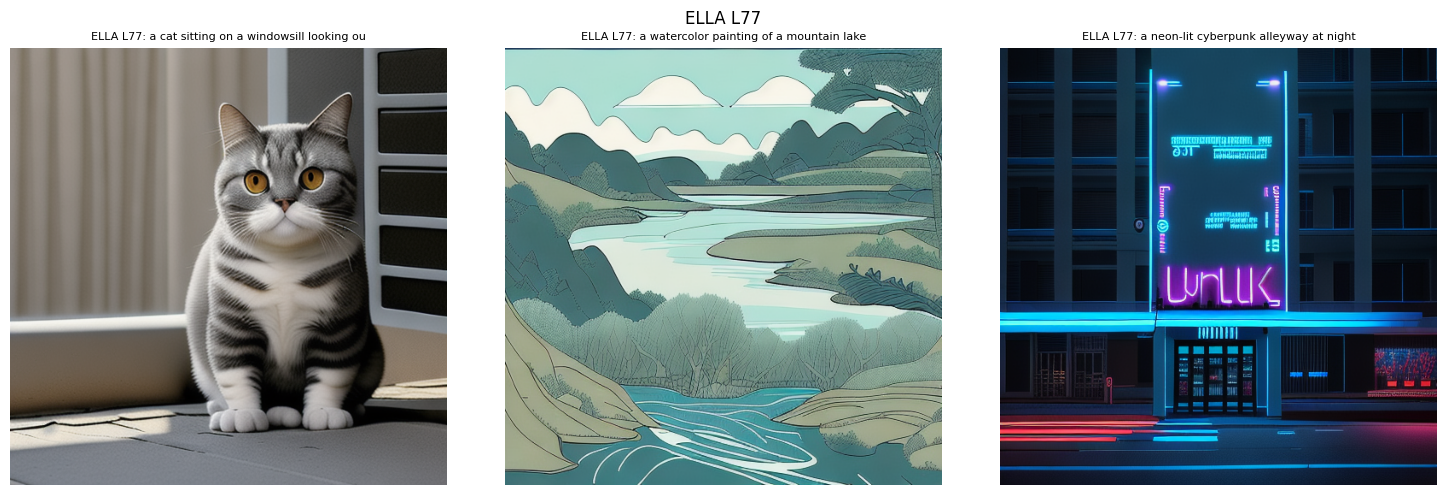

Saved: /content/drive/MyDrive/gemma3-sd-pure-ella/validation_ella_L77.png
Long-context validation grid skipped at 77-token stage


CLIP teacher:   0%|          | 0/30 [00:00<?, ?it/s]

CLIP teacher:   0%|          | 0/30 [00:00<?, ?it/s]

CLIP teacher:   0%|          | 0/30 [00:00<?, ?it/s]

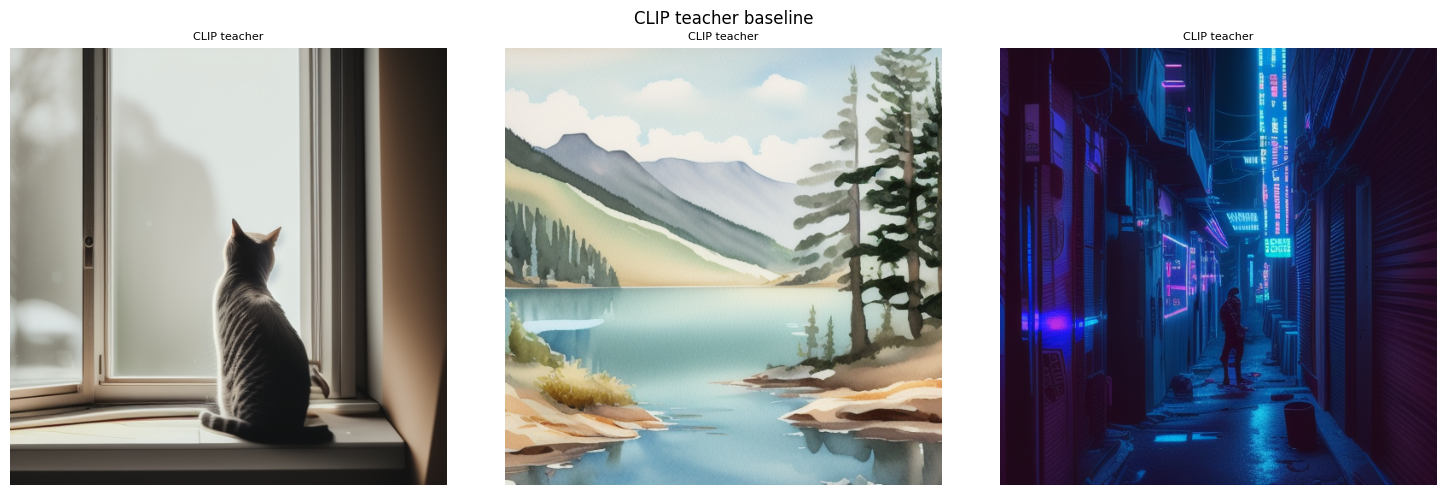

Saved: /content/drive/MyDrive/gemma3-sd-pure-ella/validation_clip_teacher.png


In [18]:
# @title 9.1 Validation grids
print("Prompt sensitivity:")
connector_prompt_sensitivity(VAL_PROMPTS, label="final_ella")
teacher_student_delta_alignment(VAL_PROMPTS[0], label="final_ella")
fixed_overfit_loss(label="final_overfit")

if RUN_FIXED_VALIDATION_GRIDS:
    ella_imgs = []
    labels = []
    for ptxt in VAL_PROMPTS:
        print("Generating ELLA:", ptxt)
        ella_imgs.append(generate_ella(ptxt, context_tokens=CONTEXT_TOKENS))
        labels.append(f"ELLA L{CONTEXT_TOKENS}: {ptxt[:40]}")
    save_validation_grid(ella_imgs, labels, f"{DRIVE_OUT}/validation_ella_L{CONTEXT_TOKENS}.png", f"ELLA L{CONTEXT_TOKENS}")

    if CONTEXT_TOKENS > CLIP_ANCHOR_TOKENS:
        long_imgs = []
        long_labels = []
        for short_prompt, long_prompt in zip(LONG_EVAL_SHORT_CONTROLS, LONG_EVAL_PROMPTS):
            long_imgs.append(generate_ella(short_prompt, context_tokens=CLIP_ANCHOR_TOKENS))
            long_labels.append(f"short L{CLIP_ANCHOR_TOKENS}")
            long_imgs.append(generate_ella(long_prompt, context_tokens=CONTEXT_TOKENS))
            long_labels.append(f"long L{CONTEXT_TOKENS}")
        save_validation_grid(long_imgs, long_labels, f"{DRIVE_OUT}/validation_long_context_L{CONTEXT_TOKENS}.png", f"Long-context ELLA L{CONTEXT_TOKENS}")
    else:
        print("Long-context validation grid skipped at 77-token stage")

    if clip_model is not None:
        clip_imgs = []
        clip_labels = []
        for ptxt in VAL_PROMPTS:
            clip_imgs.append(generate_clip_teacher(ptxt))
            clip_labels.append("CLIP teacher")
        save_validation_grid(clip_imgs, clip_labels, f"{DRIVE_OUT}/validation_clip_teacher.png", "CLIP teacher baseline")
else:
    print("Validation grids skipped")


In [19]:
# @title 9.2 Save artifacts
connector_final_path = f"{DRIVE_OUT}/pure_ella_connector_L{CONTEXT_TOKENS}.pt"
unet_sparse_path = f"{DRIVE_OUT}/pure_ella_unet_attn2_kv_sparse_L{CONTEXT_TOKENS}.pt"

torch.save({
    "architecture": "PureELLALongConnector",
    "connector_state_dict": {k: v.detach().cpu() for k, v in ella_connector.state_dict().items()},
    "connector_config": {
        "gemma_dim": gemma_hidden_size,
        "width": CONNECTOR_WIDTH,
        "context_tokens": CONTEXT_TOKENS,
        "anchor_tokens": CLIP_ANCHOR_TOKENS,
        "layers": CONNECTOR_LAYERS,
        "heads": CONNECTOR_HEADS,
        "ff_mult": CONNECTOR_FF_MULT,
        "dropout": CONNECTOR_DROPOUT,
        "time_embed_dim": CONNECTOR_TIME_EMBED_DIM,
        "extra_gate_init": CONNECTOR_EXTRA_GATE_INIT,
    },
    "gemma_model_id": GEMMA_ID,
    "sd_checkpoint": SD_CHECKPOINT,
    "run_config": RUN_CONFIG,
}, connector_final_path)
print("Connector saved:", connector_final_path)

if RUN_SARA_PHASE and sara_sparse_summary is not None:
    sparse_values = {}
    for name, p in unet.named_parameters():
        mask = getattr(p, "_sara_sparse_mask", None)
        if mask is not None:
            sparse_values[name] = {
                "mask": mask.detach().cpu().bool(),
                "values": p.detach().cpu()[mask.detach().cpu().bool()],
                "shape": tuple(p.shape),
            }
    torch.save({
        "architecture": "SD UNet original graph + sparse attn2.to_k/to_v value patch",
        "sparse_values": sparse_values,
        "sara_sparse_summary": sara_sparse_summary,
        "sd_checkpoint": SD_CHECKPOINT,
        "run_config": RUN_CONFIG,
    }, unet_sparse_path)
    print("Sparse UNet patch saved:", unet_sparse_path)
else:
    print("Sparse UNet patch skipped")


Connector saved: /content/drive/MyDrive/gemma3-sd-pure-ella/pure_ella_connector_L77.pt
Sparse UNet patch skipped


Reloading connector strict from: /content/drive/MyDrive/gemma3-sd-pure-ella/pure_ella_connector_L77.pt
Connector strict reload PASS
Reloading fresh SD checkpoint


Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Some weights of the model checkpoint were not used when initializing CLIPTextModel: 
 ['text_model.embeddings.position_ids']
In this conversion only the non-EMA weights are extracted. If you want to instead extract the EMA weights (usually better for inference), please make sure to add the `--extract_ema` flag.


Fresh reload finite forward PASS
CLIP available during proof generation: False


ELLA L77:   0%|          | 0/30 [00:00<?, ?it/s]

ELLA L77:   0%|          | 0/30 [00:00<?, ?it/s]

ELLA L77:   0%|          | 0/30 [00:00<?, ?it/s]

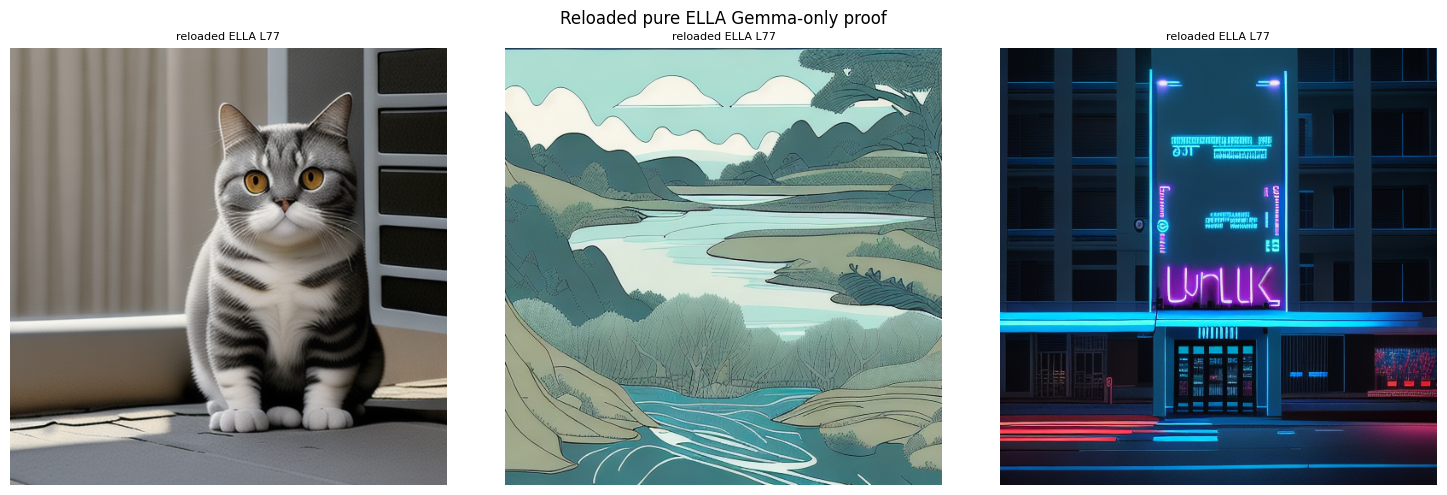

Saved: /content/drive/MyDrive/gemma3-sd-pure-ella/proof_reloaded_pure_ella_L77.png
Final proof grid: /content/drive/MyDrive/gemma3-sd-pure-ella/proof_reloaded_pure_ella_L77.png
Reloaded long-context proof skipped at 77-token stage


In [20]:
# @title 9.3 Fresh reload proof + CLIP-free generation
if RUN_FINAL_PROOF:
    print("Reloading connector strict from:", connector_final_path)
    ckpt = torch.load(connector_final_path, map_location="cpu")
    cfg = ckpt["connector_config"]
    reloaded_connector = PureELLALongConnector(**cfg).to(device=device, dtype=unet_dtype).eval()
    missing, unexpected = reloaded_connector.load_state_dict(ckpt["connector_state_dict"], strict=True)
    assert not missing and not unexpected, (missing, unexpected)
    print("Connector strict reload PASS")

    print("Reloading fresh SD checkpoint")
    reloaded_unet, _, _ = load_stylejourney_components(torch_dtype=unet_dtype, target_device=device)
    reloaded_unet.eval()
    if RUN_SARA_PHASE and os.path.exists(unet_sparse_path):
        sparse_ckpt = torch.load(unet_sparse_path, map_location="cpu")
        named = dict(reloaded_unet.named_parameters())
        patched = 0
        with torch.no_grad():
            for name, pack in sparse_ckpt["sparse_values"].items():
                if name not in named:
                    raise KeyError(name)
                p = named[name]
                mask = pack["mask"].to(device=p.device)
                vals = pack["values"].to(device=p.device, dtype=p.dtype)
                p[mask] = vals
                patched += int(mask.sum().item())
        print(f"Sparse UNet patch reload PASS: patched={patched:,}")

    with torch.no_grad():
        gh, gm = encode_gemma_prompts(["a small red car", ""])
        t = torch.tensor([500, 500], device=device).long()
        ctx = reloaded_connector(gh.to(dtype=unet_dtype), t, gm, context_tokens=CONTEXT_TOKENS)
        test_latent = torch.randn(2, 4, 64, 64, device=device, dtype=unet_dtype)
        pred = reloaded_unet(test_latent, t, encoder_hidden_states=ctx).sample
        assert torch.isfinite(pred).all()
    print("Fresh reload finite forward PASS")

    live_connector = ella_connector
    live_unet = unet
    ella_connector = reloaded_connector
    unet = reloaded_unet
    del clip_model
    del clip_tokenizer
    clip_model = None
    clip_tokenizer = None
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    try:
        assert clip_model is None and clip_tokenizer is None, "CLIP must be unloaded for CLIP-free proof"
        proof_imgs = []
        proof_labels = []
        print("CLIP available during proof generation:", clip_model is not None)
        for ptxt in VAL_PROMPTS:
            proof_imgs.append(generate_ella(ptxt, context_tokens=CONTEXT_TOKENS))
            proof_labels.append(f"reloaded ELLA L{CONTEXT_TOKENS}")
        proof_grid = f"{DRIVE_OUT}/proof_reloaded_pure_ella_L{CONTEXT_TOKENS}.png"
        save_validation_grid(proof_imgs, proof_labels, proof_grid, "Reloaded pure ELLA Gemma-only proof")
        print("Final proof grid:", proof_grid)

        if RUN_RELOADED_LONG_PROOF and CONTEXT_TOKENS > CLIP_ANCHOR_TOKENS:
            reloaded_long_imgs = []
            reloaded_long_labels = []
            for short_prompt, long_prompt in zip(LONG_EVAL_SHORT_CONTROLS, LONG_EVAL_PROMPTS):
                reloaded_long_imgs.append(generate_ella(short_prompt, context_tokens=CLIP_ANCHOR_TOKENS))
                reloaded_long_labels.append(f"reloaded short@L{CLIP_ANCHOR_TOKENS}")
                reloaded_long_imgs.append(generate_ella(long_prompt, context_tokens=CONTEXT_TOKENS))
                reloaded_long_labels.append(f"reloaded long@L{CONTEXT_TOKENS}")
            long_proof_grid = f"{DRIVE_OUT}/proof_reloaded_long_context_L{CONTEXT_TOKENS}.png"
            save_validation_grid(reloaded_long_imgs, reloaded_long_labels, long_proof_grid, f"Reloaded long-context ELLA L{CONTEXT_TOKENS}")
            print("Final long-context proof grid:", long_proof_grid)
        else:
            print("Reloaded long-context proof skipped at 77-token stage")
    finally:
        ella_connector = live_connector
        unet = live_unet
        if 'reloaded_connector' in locals():
            del reloaded_connector
        if 'reloaded_unet' in locals():
            del reloaded_unet
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
else:
    print("Final proof skipped")


In [21]:
# @title 9.4 Finish
wandb.finish()
print("Done. Runtime may be disconnected manually if desired.")


diagnostics/ella_step_000250_delta_cos,▁
diagnostics/ella_step_000250_norm_ratio,▁
diagnostics/ella_step_000500_delta_cos,▁
diagnostics/ella_step_000500_norm_ratio,▁
diagnostics/ella_step_000750_delta_cos,▁
diagnostics/ella_step_000750_norm_ratio,▁
diagnostics/ella_step_001000_delta_cos,▁
diagnostics/ella_step_001000_norm_ratio,▁
diagnostics/ella_step_001250_delta_cos,▁
diagnostics/ella_step_001250_norm_ratio,▁
+33,...


Done. Runtime may be disconnected manually if desired.


## Kill notebook

In [ ]:
import os
os.kill(os.getpid(), 9)

## Disconnection

In [1]:
from google.colab import runtime
runtime.restart_runtime()

AttributeError: module 'google.colab.runtime' has no attribute 'disconnect'